#### Supp. Fig 2b, c, d

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os 
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import seaborn as sns  
import pandas as pd  
import random
import math
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 14,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 14,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})


In [2]:
adata_unfiltered_concat = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/lambda/h5ad_401/adata_concat.h5ad")
adata_filtered_concat = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/lambda/h5ad_401/adata_filtered_concat.h5ad")

In [3]:
adata_unfiltered_concat.obs.columns

Index(['in_tissue', 'array_row', 'array_col', 'library_id', 'alignment',
       'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx',
       'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date',
       'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex',
       'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long',
       'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts',
       'n_genes'],
      dtype='object')

In [4]:
adata_unfiltered_concat.n_obs

172940

In [5]:
adata_filtered_concat.n_obs

160702

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be inte

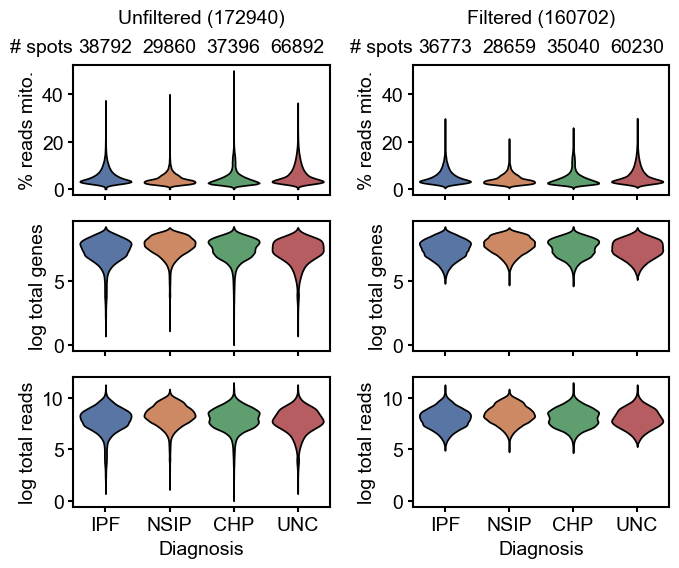

In [14]:
fig, ax = plt.subplots(3,2, figsize=(7,6))

# Flatten to ax numpy array into 1D
ax = ax.flatten()

# six plots
sc.pl.violin(adata_unfiltered_concat,'pct_counts_mt', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Diagnosis", ylabel="% reads mito.",
             show=False, ax=ax[0])
sc.pl.violin(adata_filtered_concat,'pct_counts_mt', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Diagnosis", ylabel="% reads mito.",
             show=False, ax=ax[1])
sc.pl.violin(adata_unfiltered_concat,'log1p_n_genes_by_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Diagnosis", ylabel="log total genes",
             show=False, ax=ax[2])
sc.pl.violin(adata_filtered_concat,'log1p_n_genes_by_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Diagnosis", ylabel="log total genes",
             show=False, ax=ax[3])
sc.pl.violin(adata_unfiltered_concat,'log1p_total_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Diagnosis", ylabel="log total reads",
             show=False, ax=ax[4])
sc.pl.violin(adata_filtered_concat,'log1p_total_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Diagnosis", ylabel="log total reads",
             show=False, ax=ax[5])

# set y min max for the first row of plots
y_min = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
y_max = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])

ax[0].set_ylim(y_min, y_max)
ax[1].set_ylim(y_min, y_max)
ax[0].set_title(f"Unfiltered ({adata_unfiltered_concat.n_obs})", pad = 30)
ax[1].set_title(f"Filtered ({adata_filtered_concat.n_obs})", pad = 30)

# set y min max for the second row of plots
y_min = min(ax[2].get_ylim()[0], ax[3].get_ylim()[0])
y_max = max(ax[2].get_ylim()[1], ax[3].get_ylim()[1])

ax[2].set_ylim(y_min, y_max)
ax[3].set_ylim(y_min, y_max)
ax[2].set_title("")
ax[3].set_title("")

# set y min max for the last row of plots
y_min = min(ax[4].get_ylim()[0], ax[4].get_ylim()[0])
y_max = max(ax[4].get_ylim()[1], ax[4].get_ylim()[1])

ax[4].set_ylim(y_min, y_max)
ax[5].set_ylim(y_min, y_max)
ax[4].set_title("")
ax[5].set_title("")

# Hide x axis label and title for the first two rows of plots
ax[0].set_xlabel('')  # Hide label
ax[0].set_xticklabels('')
ax[1].set_xlabel('')  # Hide label
ax[1].set_xticklabels('')
ax[2].set_xlabel('')  # Hide label
ax[2].set_xticklabels('')
ax[3].set_xlabel('')  # Hide label
ax[3].set_xticklabels('')

# Add the number of spots/obs to the first row of plots
ax[0].text(-1, 58, "# spots", 
           horizontalalignment ='center')
ax[0].text(0, 58, f"{adata_unfiltered_concat[adata_unfiltered_concat.obs["cond"]=="IPF"].n_obs}", 
           horizontalalignment ='center')
ax[0].text(1, 58, f"{adata_unfiltered_concat[adata_unfiltered_concat.obs["cond"]=="NSIP"].n_obs}", 
           horizontalalignment ='center')
ax[0].text(2, 58, f"{adata_unfiltered_concat[adata_unfiltered_concat.obs["cond"]=="CHP"].n_obs}", 
           horizontalalignment ='center')
ax[0].text(3, 58, f"{adata_unfiltered_concat[adata_unfiltered_concat.obs["cond"]=="UNC"].n_obs}", 
           horizontalalignment ='center')

ax[1].text(-1, 58, "# spots", 
           horizontalalignment ='center')
ax[1].text(0, 58, f"{adata_filtered_concat[adata_filtered_concat.obs["cond"]=="IPF"].n_obs}", 
           horizontalalignment ='center')
ax[1].text(1, 58, f"{adata_filtered_concat[adata_filtered_concat.obs["cond"]=="NSIP"].n_obs}", 
           horizontalalignment ='center')
ax[1].text(2, 58, f"{adata_filtered_concat[adata_filtered_concat.obs["cond"]=="CHP"].n_obs}", 
           horizontalalignment ='center')
ax[1].text(3, 58, f"{adata_filtered_concat[adata_filtered_concat.obs["cond"]=="UNC"].n_obs}", 
           horizontalalignment ='center')

# Adjust spacing between subplots for better visualization
plt.tight_layout(rect=[0, 0, 1, 0.985])

# Show the plots
plt.savefig("combined_qc_unfiltered_filtered.pdf")

In [ ]:
adata_unfiltered_concat.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2120,7.659643,3313.0,8.105911,26.048898,30.878358,37.488681,51.101720,538.0,6.289716,16.239059,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
AACAGGTTCACCGAAG-1-18_57617_A1,1.0,51.0,41.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2388,7.778630,3665.0,8.206857,25.702592,29.795362,35.470668,48.485675,697.0,6.548219,19.017735,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
AACAGTCAGGCTCCGC-1-18_57617_A1,1.0,24.0,6.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,4939,8.505121,10317.0,9.241645,17.514781,22.545314,28.777745,40.544732,498.0,6.212606,4.826984,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTCATTGGTCCAAG-1-22_16220_B1,1.0,55.0,99.0,22_16220_B1,man,90,91,0,0,0,0,14927,15798,V44A10-302,A1,2024-12-17,2.0.1.3,5,2024-07-01,203947,2,IPF,IPF_10,10,58,F,26,45.0,64.0,39.0,NaN,ALIVE,34,ALIVE,24,right,middle,7129,8.872067,19251.0,9.865370,16.149810,20.637889,26.414212,37.296764,781.0,6.661855,4.056932,0.0,0.0,0.0,0.0,0.0,0.0,19251.0,7129.0
TGTTGCGTCCAAGATT-1-22_16220_B1,1.0,51.0,65.0,22_16220_B1,man,90,91,0,0,0,0,14927,15798,V44A10-302,A1,2024-12-17,2.0.1.3,5,2024-07-01,203947,2,IPF,IPF_10,10,58,F,26,45.0,64.0,39.0,NaN,ALIVE,34,ALIVE,24,right,middle,3768,8.234565,7184.0,8.879751,19.724388,24.972160,31.556236,44.863586,362.0,5.894403,5.038976,0.0,0.0,0.0,0.0,0.0,0.0,7184.0,3768.0
TGTTGGAAGCTCGGTA-1-22_16220_B1,1.0,1.0,95.0,22_16220_B1,man,90,91,0,0,0,0,14927,15798,V44A10-302,A1,2024-12-17,2.0.1.3,5,2024-07-01,203947,2,IPF,IPF_10,10,58,F,26,45.0,64.0,39.0,NaN,ALIVE,34,ALIVE,24,right,middle,3776,8.236685,6059.0,8.709465,15.118006,19.590692,25.383727,37.629972,192.0,5.262690,3.168840,0.0,0.0,0.0,0.0,0.0,0.0,6059.0,3776.0
TGTTGGATGGACTTCT-1-22_16220_B1,1.0,13.0,53.0,22_16220_B1,man,90,91,0,0,0,0,14927,15798,V44A10-302,A1,2024-12-17,2.0.1.3,5,2024-07-01,203947,2,IPF,IPF_10,10,58,F,26,45.0,64.0,39.0,NaN,ALIVE,34,ALIVE,24,right,middle,2730,7.912423,4281.0,8.362176,19.504789,24.550339,31.558047,45.877132,284.0,5.652489,6.633964,0.0,0.0,0.0,0.0,0.0,0.0,4281.0,2730.0


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_82877/4073551110.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_unfiltered_concat[adata_unfiltered_concat.obs['library_id']=="18_57617_A1"],
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_82877/4073551110.py:18: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_filtered_concat[adata_filtered_concat.obs['library_id']=="18_57617_A1"],


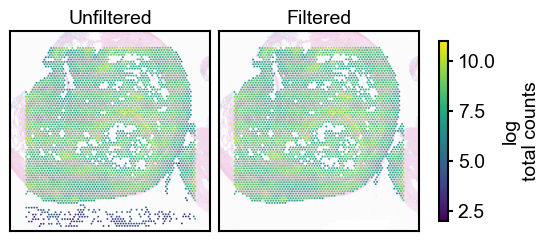

In [97]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.7 * n_cols, 2.7 * n_rows), sharey=True,constrained_layout=True)
axes = axes.flatten()



sc.pl.spatial(adata_unfiltered_concat[adata_unfiltered_concat.obs['library_id']=="18_57617_A1"],
              library_id="18_57617_A1", 
              color = 'log1p_total_counts',
              ax = axes[0],
              alpha_img=0.2,
              vmin = 2, vmax = 11,
              show=False,
              colorbar_loc= None,
              title = "")
axes[0].set_title("Unfiltered", pad =5)

sc.pl.spatial(adata_filtered_concat[adata_filtered_concat.obs['library_id']=="18_57617_A1"],
              library_id="18_57617_A1", 
              color = 'log1p_total_counts',
              ax = axes[1],
              alpha_img=0.2,
              vmin = 2, vmax = 11,
              show=False,
              colorbar_loc= None,
              title= "")
axes[1].set_title("Filtered", pad =5)

for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)

# Add a completely separate colorbar
norm = mcolors.Normalize(vmin=2, vmax=11)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])  # needed for ScalarMappable

# Draw colorbar in a new figure or on the side of the current figure
cbar = fig.colorbar(sm, ax=axes, fraction=0.022)
cbar.set_label("log\ntotal counts")
#plt.tight_layout()
plt.savefig("spot_filter_example_1.pdf", bbox_inches = 'tight', transparent = True)
plt.show()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_82877/600455487.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_unfiltered_concat[adata_unfiltered_concat.obs['library_id']=="21_06301_B2"],
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_82877/600455487.py:19: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_filtered_concat[adata_filtered_concat.obs['library_id']=="21_06301_B2"],


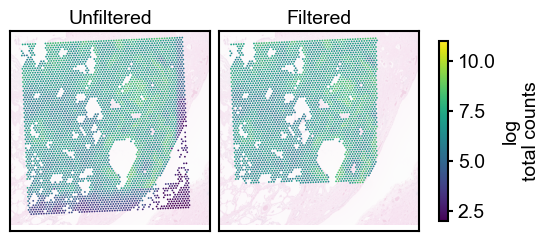

In [98]:
n_rows, n_cols = 1,2
fig, axes = plt.subplots(n_rows, n_cols, figsize = (2.7 * n_cols, 2.7 * n_rows), sharey=True,constrained_layout=True)
axes = axes.flatten()



sc.pl.spatial(adata_unfiltered_concat[adata_unfiltered_concat.obs['library_id']=="21_06301_B2"],
              library_id="21_06301_B2", 
              color = 'log1p_total_counts',
              ax = axes[0],
              alpha_img=0.2,
              vmin = 2, vmax = 11,
              show=False,
              colorbar_loc= None,
              title = "")
axes[0].set_title("Unfiltered", pad =5)


sc.pl.spatial(adata_filtered_concat[adata_filtered_concat.obs['library_id']=="21_06301_B2"],
              library_id="21_06301_B2", 
              color = 'log1p_total_counts',
              ax = axes[1],
              alpha_img=0.2,
              vmin = 2, vmax = 11,
              show=False,
              colorbar_loc= None,
              title= "")
axes[1].set_title("Filtered", pad =5)

for i in range(len(axes)):

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0,2000)
    axes[i].set_ylim(2000,0)

# Add a completely separate colorbar
norm = mcolors.Normalize(vmin=2, vmax=11)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])  # needed for ScalarMappable

# Draw colorbar in a new figure or on the side of the current figure
cbar = fig.colorbar(sm, ax=axes, fraction=0.022)
cbar.set_label("log\ntotal counts")
#plt.tight_layout()
plt.savefig("spot_filter_example_2.pdf", bbox_inches = 'tight', transparent = True)
plt.show()

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which 

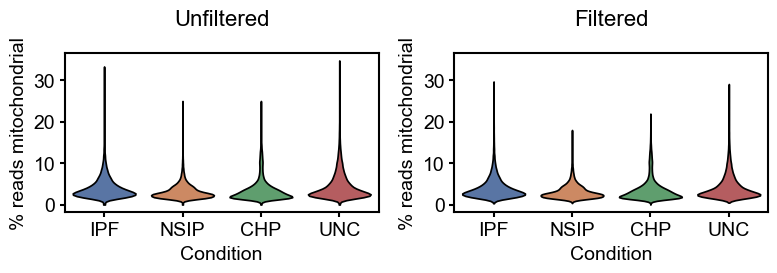

In [7]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
sc.pl.violin(adata_unfiltered_concat,'pct_counts_mt', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="% reads mitochondrial",
             show=False, ax=ax[0])
sc.pl.violin(adata_filtered_concat,'pct_counts_mt', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="% reads mitochondrial",
             show=False, ax=ax[1])
y_min = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
y_max = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])

ax[0].set_ylim(y_min, y_max)
ax[1].set_ylim(y_min, y_max)
ax[0].set_title("Unfiltered")
ax[1].set_title("Filtered")

# Adjust spacing between subplots for better visualization
plt.tight_layout(rect=[0, 0, 1, 0.985])

# Show the plots
plt.savefig("pct_mito_unfiltered_v_filtered.pdf")


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which 

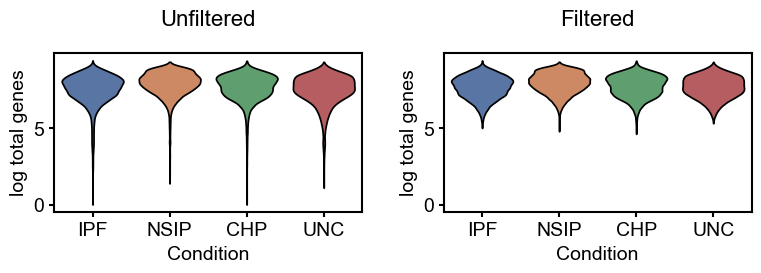

In [8]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
sc.pl.violin(adata_unfiltered_concat,'log1p_n_genes_by_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="log total genes",
             show=False, ax=ax[0])
sc.pl.violin(adata_filtered_concat,'log1p_n_genes_by_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="log total genes",
             show=False, ax=ax[1])
y_min = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
y_max = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])

ax[0].set_ylim(y_min, y_max)
ax[1].set_ylim(y_min, y_max)
ax[0].set_title("Unfiltered")
ax[1].set_title("Filtered")

# Adjust spacing between subplots for better visualization
plt.tight_layout(rect=[0, 0, 1, 0.985])

# Show the plots
plt.savefig("log_total_genes_unfiltered_v_filtered.pdf")


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which 

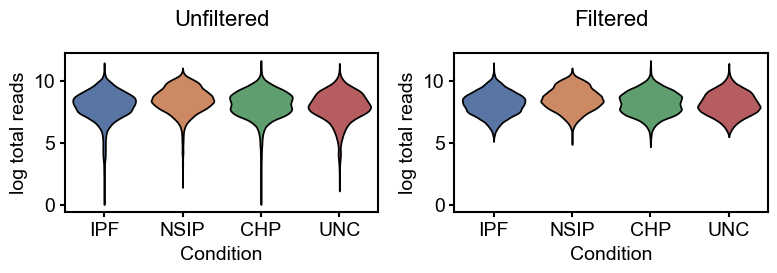

In [9]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
sc.pl.violin(adata_unfiltered_concat,'log1p_total_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="log total reads",
             show=False, ax=ax[0])
sc.pl.violin(adata_filtered_concat,'log1p_total_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
             palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="log total reads",
             show=False, ax=ax[1])
y_min = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
y_max = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])

ax[0].set_ylim(y_min, y_max)
ax[1].set_ylim(y_min, y_max)
ax[0].set_title("Unfiltered")
ax[1].set_title("Filtered")

# Adjust spacing between subplots for better visualization
plt.tight_layout(rect=[0, 0, 1, 0.985])

# Show the plots
plt.savefig("log_total_reads_unfiltered_v_filtered.pdf")


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.violinplot(


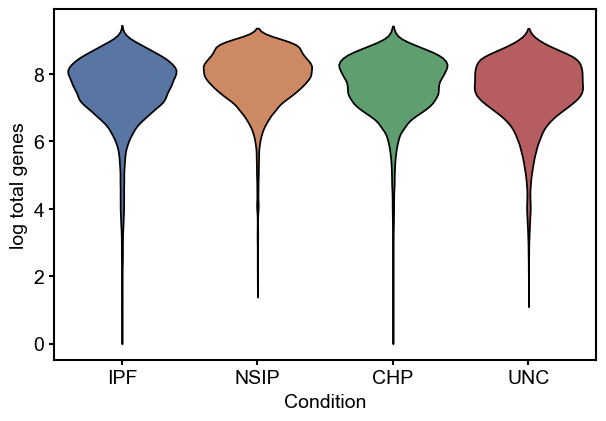

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.violinplot(


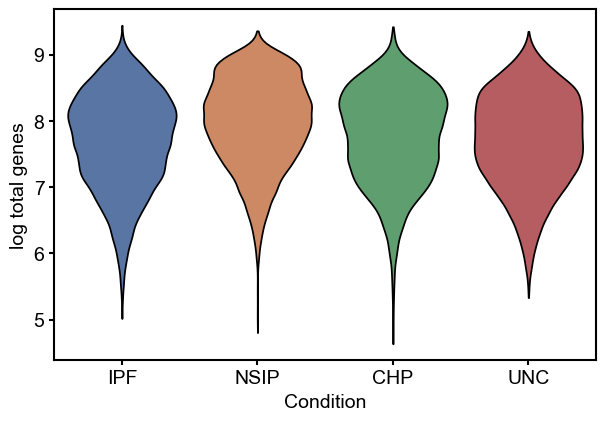

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.violinplot(


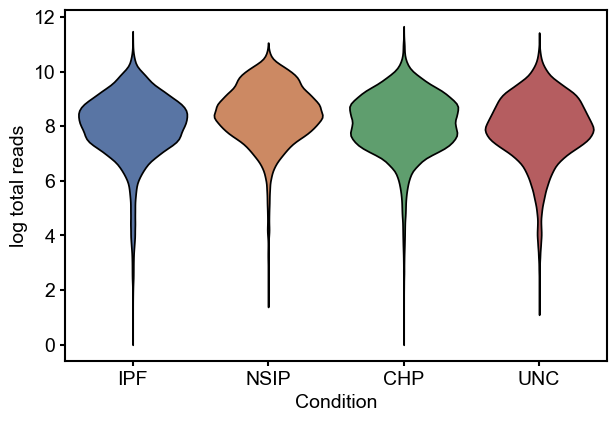

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.violinplot(


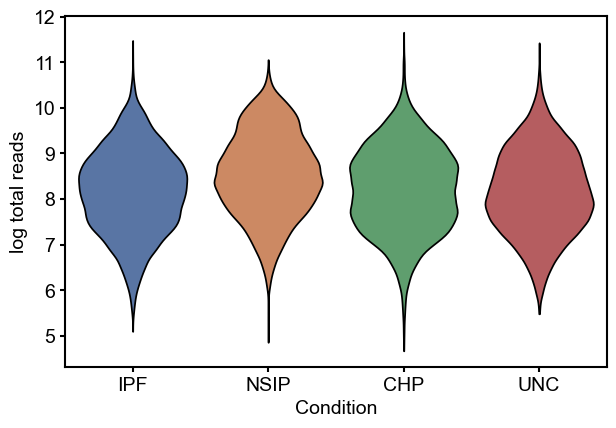

In [ ]:

# sc.pl.violin(adata_unfiltered_concat,'log1p_n_genes_by_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
#              palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="log total genes")
# sc.pl.violin(adata_filtered_concat,'log1p_n_genes_by_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
#              palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="log total genes")

# sc.pl.violin(adata_unfiltered_concat,'log1p_total_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
#              palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="log total reads")
# sc.pl.violin(adata_filtered_concat,'log1p_total_counts', groupby='cond', stripplot=False, order=['IPF','NSIP','CHP','UNC'], 
#              palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Condition", ylabel="log total reads")

/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:967: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.violinplot(


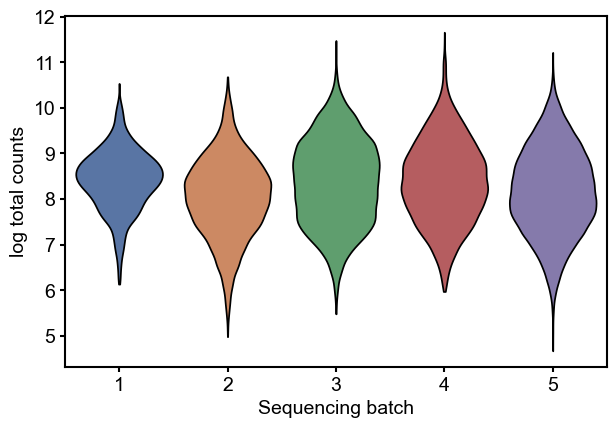

In [ ]:
# sc.pl.violin(adata_filtered_concat,'log1p_total_counts', groupby='seq_batch', stripplot=False, #order=['IPF','NSIP','CHP','UNC'], 
#              palette=sns.color_palette("deep"), fill=True, linecolor='black', xlabel="Sequencing batch", ylabel="log total counts")